In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [17]:
import os
import requests

USE_LOCAL = True
LOCAL_FILE = "Indian_names_kaggle.txt"
url = "https://raw.githubusercontent.com/abhishek-marathe04/makemore/refs/heads/main/Indian_names_kaggle.txt"

def load_words_from_text(text: str):
    return text.replace(".", "").lower().splitlines()

words = None

if USE_LOCAL:
    local_path = os.path.join(os.getcwd(), LOCAL_FILE)
    if os.path.exists(local_path):
        with open(local_path, "r", encoding="utf-8") as f:
            words = load_words_from_text(f.read())
        print(f"Loaded {len(words)} names from local file: {local_path}")
    else:
        print(f"Local file not found ({local_path}). Falling back to download...")

if words is None:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    words = load_words_from_text(response.text)
    print(f"Downloaded {len(words)} names from URL.")

Loaded 55689 names from local file: /Users/abhishekmarathe/workspace/Learning/makemore/Indian_names_kaggle.txt


In [18]:
# Build the vocabulary of characters and mappings to/from integers
# print(sorted(list(set(''.join(words)))))
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)

print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [19]:
# Building a Dataset

import torch
import random

block_size = 3

def build_dataset(words):
  print(len(words))
  X = []
  Y = []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)

      # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
      context = context[1:] + [ix]


  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

44551
5569
5569


In [22]:
# MLP Revisted

n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(vocab_size, n_embd,             generator=g)
W1 = torch.randn(n_embd * block_size, n_hidden ,generator=g) * (5/3)/((n_embd * block_size) ** 0.5)
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn(n_hidden, vocab_size,          generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

bngain = torch.ones(1, n_hidden)
bnbias = torch.zeros(1, n_hidden)

bnmean_running = torch.ones(1, n_hidden)
bnstd_running = torch.ones(1, n_hidden)

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
# print("Model initilised..")
print(f"Hidden Layers : {n_hidden}, embedding_dims : {n_embd}, input_values {vocab_size}, output_values: {vocab_size}")
print(f"Number of parameters in model {sum(p.nelement() for p in parameters)}") # Number of parameters in model

for p in parameters:
    p.requires_grad = True

Hidden Layers : 200, embedding_dims : 10, input_values 27, output_values: 27
Number of parameters in model 12297


In [23]:
max_steps = 20000
batch_size = 32
lossi = []

# Lets run for 30000 iterations on XTr (Xtrain)
for i in range(max_steps):
    
    # Mini batch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,)) # We will form minibatch using this
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch x,y


    # Forward pass
    emb = C[Xb] # (37,3, 2) # Embed characters into vectors
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors

    hpreact = embcat @ W1 + b1 # hidden layer pre activation

    # lets look at batch norm, We are standartiing this batch, but this should only applicable to init,
    # For that, we need to add scale and shift
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi  + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact) # (37,100)  # hidden layer
    logits = h @ W2 + b2 # 37,27 # output layer
    # loss
    loss = F.cross_entropy(logits, Yb)

    
    # Backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    
    # Update parameters
    lr = 0.1 if i < 10000 else 0.01 # step learning rate decay
    # print(parameters)
    ixfrtr = 0
    for p in parameters:
        ixfrtr += 1
        p.data += -lr * p.grad


    # Track Status
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():4f}')
    lossi.append(loss.log10().item())

    break


      0/  20000: 3.287516


(array([159., 177., 210., 182., 167., 154., 123., 168., 135., 172., 107.,
        127., 114., 119.,  73., 111.,  94., 113., 105., 123., 104., 103.,
         90.,  87., 112.,  99.,  86.,  86., 115., 118.,  96., 103.,  79.,
         96.,  95., 106., 127., 113., 101., 128., 143., 151., 103., 130.,
        140., 149., 203., 217., 222., 165.]),
 array([-0.99668968, -0.95688234, -0.917075  , -0.87726766, -0.83746032,
        -0.79765298, -0.75784564, -0.7180383 , -0.67823096, -0.63842362,
        -0.59861628, -0.55880894, -0.5190016 , -0.47919426, -0.43938692,
        -0.39957958, -0.35977224, -0.3199649 , -0.28015756, -0.24035022,
        -0.20054288, -0.16073554, -0.1209282 , -0.08112086, -0.04131352,
        -0.00150618,  0.03830116,  0.0781085 ,  0.11791584,  0.15772318,
         0.19753052,  0.23733786,  0.2771452 ,  0.31695254,  0.35675988,
         0.39656722,  0.43637456,  0.4761819 ,  0.51598924,  0.55579658,
         0.59560392,  0.63541126,  0.6752186 ,  0.71502594,  0.75483328,
 

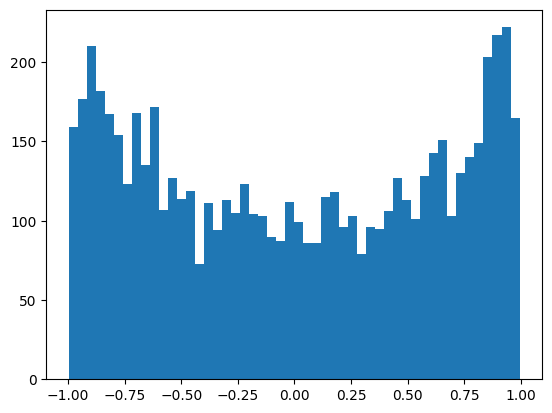

In [24]:
# We can see, Most of the values are either -1 or 1, and all these values that are 1 or -1 are in flat
# region of tanh, And what will happen is, gradients will be vanished ( check tanh formula for gradient)

plt.hist(h.view(-1).tolist(), 50)

(array([  2.,   0.,   3.,   3.,   8.,   3.,  10.,  25.,  29.,  34.,  64.,
         58.,  67., 101., 125., 137., 165., 176., 185., 245., 284., 263.,
        248., 282., 320., 281., 301., 320., 260., 257., 283., 244., 260.,
        183., 171., 170., 155., 141., 138., 114.,  76.,  55.,  62.,  33.,
         25.,   8.,  10.,   8.,   4.,   4.]),
 array([-3.20110321, -3.0795452 , -2.95798718, -2.83642917, -2.71487116,
        -2.59331315, -2.47175513, -2.35019712, -2.22863911, -2.10708109,
        -1.98552308, -1.86396507, -1.74240705, -1.62084904, -1.49929103,
        -1.37773302, -1.256175  , -1.13461699, -1.01305898, -0.89150096,
        -0.76994295, -0.64838494, -0.52682693, -0.40526891, -0.2837109 ,
        -0.16215289, -0.04059487,  0.08096314,  0.20252115,  0.32407917,
         0.44563718,  0.56719519,  0.6887532 ,  0.81031122,  0.93186923,
         1.05342724,  1.17498526,  1.29654327,  1.41810128,  1.5396593 ,
         1.66121731,  1.78277532,  1.90433333,  2.02589135,  2.14744936,
 

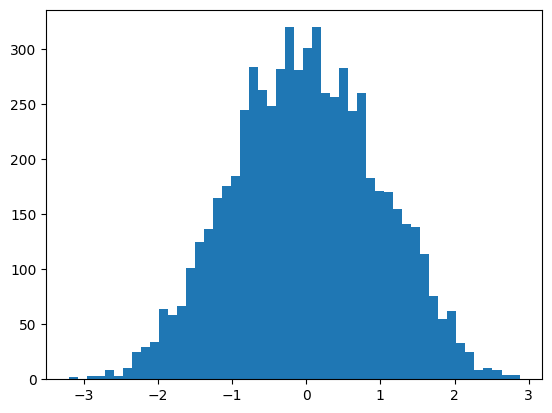

In [25]:
# Lets check pre activation, as we can see, its taking really brod values
plt.hist(hpreact.view(-1).tolist(), 50)

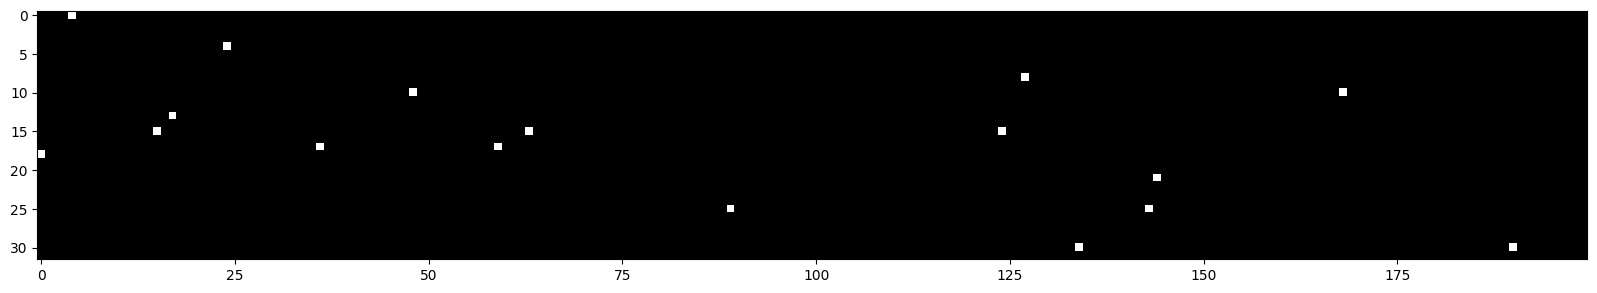

In [26]:
# Following figure shows, all these white spaces indicate, tanh layer is really active in that neuron
# If lets say whole column is white, then its a dead nueron, in that case, no single example ever activates tanh
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # This is boolean tensor, you get white if true, or black

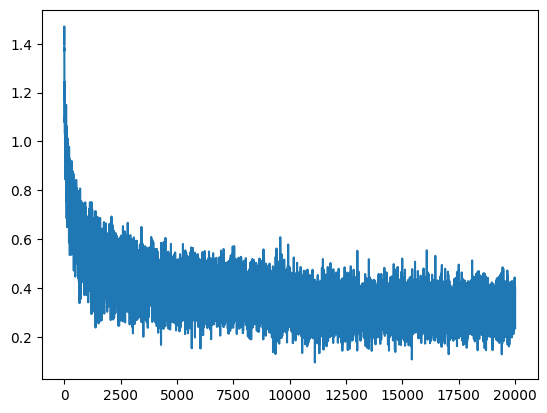

In [7]:
plt.plot(lossi)

tensor(0.0103) tensor(1.0028)
tensor(-0.0001) tensor(0.9820)


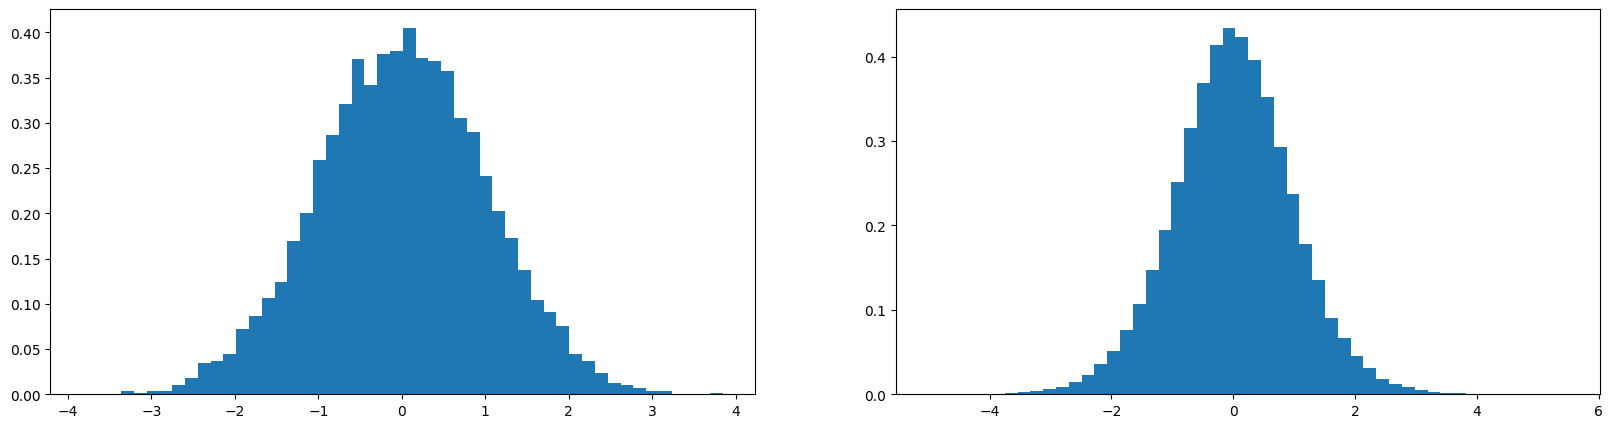

In [27]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * 0.1 # As we can see, if we dont scale 2, y is taking huge values, so we need to reduce it, but question is by how much
# Mathematically, its sqaure root of fan_in ( which is input, in this case 10) 
# There is paper on this one, where they mentioned term kiamining init,
# So what happens is, as tanh is quashing function, we want some gain to make to more gaussian and equally distributed,
# That number is called as kiaming gain, it depends on actiation function you are using, for tanh, its (5/3) / square root of fan_in
w = torch.randn(10, 200) / 10 ** 0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50,  density=True);

In [ ]:
# Fixing the initial loss.
# In first iteration, our model has around loss of 25, 
# So 25% of time, our model is wrong, but that should not be the case, our model should be initilised such that, there should equal probablity model should give to each 27 characters
# That is
-torch.tensor(1/27).log()
# So initial log should be around 3, we are having very huge initilial loss as model is randomly assinging weights, and giving some numbers high weight which makes it more confident of them.

tensor(3.2958)

In [28]:
# 4 dimensional example of the issue
# logits = torch.tensor([15.0, 10.0, 5.0, 12.0])
logits = torch.randn(4) * 0.01
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, loss

(tensor([-0.0116,  0.0151,  0.0075, -0.0040]), tensor(1.3806))

In [ ]:
@torch.no_grad() # this decorator will disable gradient tracking inside this function, which is useful for inference and evaluation
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # Contact into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")


split_loss('train')
split_loss('val')


train loss: 2.0915
val loss: 2.0989


### First iteration, without any tweak 
- train loss: 2.0915
- val loss: 2.0989

### Second iteration, after initialising W2 And b2 - Fixing softmax confidently wrong
- train loss: 1.9806
- val loss: 1.9940

## Third iteration, Fix tanh layer too saturated at init
- train loss: 1.9678
- val loss: 1.9734

## Fourth Iteration, kiaming init
- train loss: 1.9607
- val loss: 1.9676


In [9]:
# Lets now Sample from our model

g = torch.Generator().manual_seed(2147483647 + 102) # for reproducability

for _ in range(20):

  out = []
  context = [0] * block_size # Initilise with all ...
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (37,100)
    logits = h @ W2 + b2 # 37,27
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

dharshini.
hamatriyyan.
bhakattag.
selvtungavidh.
chan.
vaimtrumaharshindu.
chanthan.
cpaya.
ayyakidyalath.
mathesh.
kaarejulith.
kagmisadhika.
shrarja.
joajanu.
kula.
poran.
arbak.
naru.
ruti.
kalash.
